In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [3]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [4]:
bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'

In [ ]:
import re


pts = BIDSPath(
    root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
    datatype='epoch(band)(sig)(effective)',
    suffix='highgamma',
    extension='.h5',
    description='Repeat',
    processing='Go',
    check=False
).match()


def create_trial_ids(group):
    condition = group['condition'].iloc[0]  
    return [f"{condition}_{i+1}" for i in range(len(group))]

epos = []
for pt in pts[:5]:
    epo = mne.read_epochs(pt, verbose='error')
    df = epo.to_data_frame(long_format=True, verbose='error')
    # 平均 channel，保留 trial 作为观测
    # df['condition'] = df['condition'].str.extract(r'(Word|Nonword)/[^/]+')
    df['condition'] = df['condition'].str.split('/').str[3:4].str.join('/')
    df['description'] = pt.description
    df['phase'] = pt.processing.lower()
    df['subject'] = pt.subject

    epoch_conditions = df.groupby('epoch')['condition'].first()
    condition_counts = epoch_conditions.groupby(epoch_conditions).cumcount() + 1
    trial_map = epoch_conditions + '_' + condition_counts.astype(str)

    df['trial'] = df['epoch'].map(trial_map)
    df = df.drop(columns=['ch_type'])
    epos.append(df)
    
epos = pd.concat(epos, ignore_index=True)
epos.head()

,condition,epoch,time,channel,value,description,phase,subject,trial
0,uga,2,-1.000000,D0019_RLSO7-8,-119.596452,Repeat,go,D0019,uga_1
1,uga,2,-1.000000,D0019_RMOS3-4,497.841686,Repeat,go,D0019,uga_1
2,uga,2,-0.992188,D0019_RLSO7-8,-102.455892,Repeat,go,D0019,uga_1
3,uga,2,-0.992188,D0019_RMOS3-4,287.709057,Repeat,go,D0019,uga_1
4,uga,2,-0.984375,D0019_RLSO7-8,-103.372887,Repeat,go,D0019,uga_1


In [6]:
deco = (epos
    .groupby(['trial','channel','time'])['value']
    .mean()
    .to_xarray()
    )

In [7]:
deco

<xarray.DataArray 'value' (trial: 208, channel: 42, time: 320)> Size: 22MB
array([[[-5.45587599e+02, -5.38140774e+02, -5.36666155e+02, ...,
         -5.62633634e+02, -5.49496889e+02, -5.22224486e+02],
        [-1.62326455e+03, -1.55171132e+03, -1.51476681e+03, ...,
          1.31806576e+03,  1.39947164e+03,  1.44128561e+03],
        [-1.03875911e+03, -8.79631221e+02, -6.48314774e+02, ...,
         -1.03301191e+03, -1.07496452e+03, -1.07701397e+03],
        ...,
        [-1.91737995e+02, -2.02883288e+02, -2.24014238e+02, ...,
         -7.28399828e+01, -9.31134373e+01, -7.95899332e+01],
        [ 8.50459874e+02,  1.05570090e+03,  1.43025613e+03, ...,
          1.87844491e+03,  2.00907540e+03,  1.95073438e+03],
        [-1.23356550e+00,  8.06327313e+01,  2.01378673e+02, ...,
          6.38008595e+02,  5.69503605e+02,  5.24345636e+02]],

       [[-3.62027377e+02, -4.03363913e+02, -4.39395219e+02, ...,
         -3.39386106e+02, -3.43368024e+02, -3.45357746e+02],
        [-3.37777019e+02, -6.04872286e+02, -9.24998164e+02, ...,
         -1.82944849e+02, -1.48818538e+02, -2.59016722e+02],
        [-7.37156928e+02, -9.16866064e+02, -1.08629155e+03, ...,
          1.22061813e+03,  1.64502287e+03,  1.84838772e+03],
...
        [-3.70094739e+01, -6.93276227e+01, -1.15771577e+02, ...,
         -2.41351724e+02, -2.32390925e+02, -2.05938339e+02],
        [-6.16238594e+02, -4.28370893e+02, -2.45810479e+02, ...,
         -1.19827592e+03, -1.10366189e+03, -9.58656728e+02],
        [ 1.68372672e+01,  2.92229913e+01,  1.87303443e+01, ...,
          8.09752196e+01, -1.02671934e+00, -1.26670137e+02]],

       [[-4.04858261e+02, -4.24387306e+02, -4.49426413e+02, ...,
         -2.28781775e+02, -2.41196886e+02, -2.60097623e+02],
        [-6.79870427e+02, -8.17603290e+02, -8.32207382e+02, ...,
          7.08994150e+02,  5.19485533e+02,  3.94281954e+02],
        [-5.90768278e+02, -5.00557363e+02, -3.02745372e+02, ...,
         -4.97297198e+02, -1.14483520e+02,  5.73939085e+02],
        ...,
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan],
        [            nan,             nan,             nan, ...,
                     nan,             nan,             nan]]])
Coordinates:
  * trial    (trial) object 2kB 'abae_1' 'abae_2' 'abae_3' ... 'vuk_3' 'vuk_4'
  * channel  (channel) object 336B 'D0019_RLSO7-8' ... 'D0028_LPST3-6'
  * time     (time) float64 3kB -1.0 -0.9922 -0.9844 ... 1.477 1.484 1.492

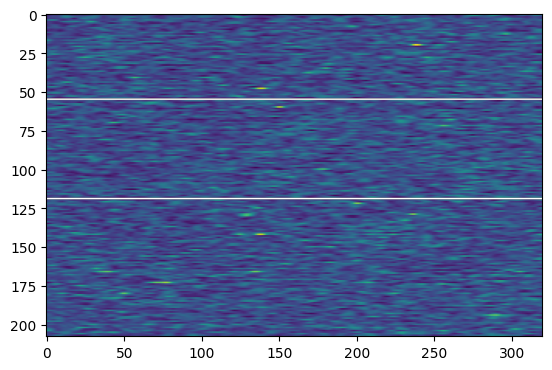

In [8]:
plt.imshow(deco[:,10])